# Final Project - DD2358
## Navier-Stokes Solver Optimization
Axel Ericson Holmgren, Jonathan Fransson, Kasper Malm

## Profiling
=====================================================================================

### cProfile

In [1]:
# cProfiling, printing cumulative time to file cprofiling-ns.txt
# !python profiling-original-code\computation\cprofile\cprofiling-ns.py

navier_stokes_spectral.py:88: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


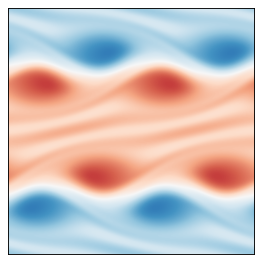

<Figure size 640x480 with 0 Axes>

         2065677 function calls (2049405 primitive calls) in 50.827 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    24/23    0.001    0.000   50.960    2.216 base_events.py:1966(_run_once)
       23    4.200    0.183   50.825    2.210 selectors.py:540(select)
    27000    1.171    0.000   38.872    0.001 _pocketfft.py:741(_raw_fftnd)
    54000   37.474    0.001   37.505    0.001 _pocketfft.py:58(_raw_fft)
    15000    0.013    0.000   20.621    0.001 _pocketfft.py:887(ifftn)
    30000    0.020    0.000   20.057    0.001 _pocketfft.py:219(ifft)
    12000    0.011    0.000   18.278    0.002 _pocketfft.py:755(fftn)
    24000    0.016    0.000   17.493    0.001 _pocketfft.py:120(fft)
     3000    2.512    0.001   15.601    0.005 navier_stokes_spectral.py:31(grad)
     1000    1.319    0.001    6.976    0.007 navier_stokes_spectral.py:39(div)
     1000    1.258    0.001    6.849    0.007 navier_stokes_spectral.py:46(curl)


In [2]:
%run -m cProfile -s cumtime navier_stokes_spectral.py

### Line_profiler

In [3]:
!python -m kernprof -l -v profiling-original-code/computation/line_profiler/line_profiling-ns.py

/opt/homebrew/opt/python@3.14/bin/python3.14: No module named kernprof


### Memory_Profiler

Memory_Profiler output in notebook

In [4]:
!python -m memory_profiler profiling-original-code/memory/memory_profiler/memory_profiling-ns.py

/opt/homebrew/opt/python@3.14/bin/python3.14: No module named memory_profiler


Memory_Profiler output to .txt file

In [5]:
%run -m memory_profiler profiling-original-code/memory/memory_profiler/memory_profiling-ns.py 2>&1 > profiling-original-code/memory/memory_profiler/memory_profile_ns.txt

/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib/python3.14/site-packages/memory_profiler.py:752: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if iscoroutinefunction(func):
profiling-original-code/memory/memory_profiler/memory_profiling-ns.py:102: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.010000000000000002
Filename: profiling-original-code/memory/memory_profiler/memory_profiling-ns.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    66  260.719 MiB  260.719 MiB           1   @profile
    67                                         def main():
    68                                             """Navier-Stokes Simulation"""
    69                                         
    70                                             # Simulation parameters
    71  260.734 MiB    0.016 MiB           1       N = 400  # Spatial resolution
    72  260.734 MiB    0.000 MiB           1       t = 0  # current time of the simulation
    73                                         
    74                                             # Changed for testing:
    75                                             # tEnd = 1  # time at which simulation ends
    76  260.734 MiB    0.000 MiB           1       tEnd = 

In [6]:
# Running and saving in correct folder
# %cd profiling-original-code/memory/memory_profiler
!: > profiling-original-code/memory/memory_profiler/memory_profile.dat

%run -m mprof run -o profiling-original-code/memory/memory_profiler/memory_profile.dat profiling-original-code/memory/memory_profiler/memory_profiling-ns.py 

mprof.py: Sampling memory every 0.1s
running new process
running as a Python program...


profiling-original-code/memory/memory_profiler/memory_profiling-ns.py:102: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.010000000000000002


In [7]:
# Running and saving in the correct folder
%run -m mprof plot profiling-original-code/memory/memory_profiler/memory_profile.dat -o profiling-original-code/memory/memory_profiler/memory_plot.png

## Optimization
=====================================================================================

### Cython compiled code

Done: 

Baseline without pyfftw: 

    cProfile: 50.8 s 

Created Cython framwork.
Type annotation for varibles
Changed fft backend to pyfftw with numpy wrappers. 
Added more aggressive compile arguments in setup.py

    *cProfile: 47 to 48s 

Python with pyfftw:

    *cProfile: 20.2 s 


In [1]:
%run cython/setup.py build_ext --build-lib cython/build/ --build-temp cython/build/
#%run cython/setup.py build_ext --help

Compiling cython/navier_stokes_spectral_c.pyx because it changed.
[1/1] Cythonizing cython/navier_stokes_spectral_c.pyx



Error compiling Cython file:
------------------------------------------------------------
...
    """solve the Poisson equation, given source field rho"""

    cdef cnp.ndarray[cnp.complex128_t, ndim=2] V_hat
    cdef cnp.ndarray[cnp.float64_t, ndim=2] V

    V_hat = -(fft.fftn(rho)) * kSq_inv
              ^
------------------------------------------------------------
cython/navier_stokes_spectral_c.pyx:38:14: undeclared name not builtin: fft


CompileError: cython/navier_stokes_spectral_c.pyx

Analysis of Python and C interplay

In [2]:
from IPython.display import HTML
%run -m cython -a cython/navier_stokes_spectral_c.pyx
HTML(filename="cython/navier_stokes_spectral_c.html")


Error compiling Cython file:
------------------------------------------------------------
...
    """solve the Poisson equation, given source field rho"""

    cdef cnp.ndarray[cnp.complex128_t, ndim=2] V_hat
    cdef cnp.ndarray[cnp.float64_t, ndim=2] V

    V_hat = -(fft.fftn(rho)) * kSq_inv
              ^
------------------------------------------------------------
cython/navier_stokes_spectral_c.pyx:38:14: undeclared name not builtin: fft


SystemExit: 1

/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3037: UserWarning: Unknown failure executing module: <cython>
  warn('Unknown failure executing module: <%s>' % mod_name)


#### cProfile for C complied code

In [4]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral.py

cython/navier_stokes_spectral.py:21: RuntimeWarning: overflow encountered in multiply
  return ns_c.main()
cython/navier_stokes_spectral.py:21: RuntimeWarning: invalid value encountered in add
  return ns_c.main()


         3054 function calls (3048 primitive calls) in 12.513 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.265    0.132   12.285   12.285 {built-in method builtins.exec}
      227   12.192    0.054   12.194    0.054 {built-in method time.sleep}
      2/1    0.001    0.000    6.124    6.124 navier_stokes_spectral.py:1(<module>)
        1    0.002    0.002    6.124    6.124 navier_stokes_spectral.py:24(main)
        4    0.000    0.000    5.897    1.474 base_events.py:1966(_run_once)
        4    0.001    0.000    5.896    1.474 selectors.py:540(select)
        1    0.023    0.023    0.023    0.023 navier_stokes_spectral.py:20(run_navier_stokes)
        4    0.018    0.004    0.018    0.004 {method 'control' of 'select.kqueue' objects}
        1    0.001    0.001    0.005    0.005 _function_base_impl.py:5050(meshgrid)
        4    0.003    0.001    0.003    0.001 {method 'copy' of 'numpy.ndarray' objects}


cython/navier_stokes_spectral_pyfftw_baseline.py:63: RuntimeWarning: divide by zero encountered in divide
  kSq_inv[kSq == 0] = 1


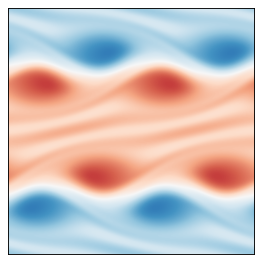

<Figure size 640x480 with 0 Axes>

         512188 function calls (511309 primitive calls) in 20.233 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       14    0.050    0.004   20.737    1.481 base_events.py:1966(_run_once)
      2/1    0.008    0.004   20.021   20.021 {built-in method builtins.exec}
        1    0.002    0.002   20.021   20.021 navier_stokes_spectral_pyfftw_baseline.py:1(<module>)
  374/373    3.806    0.010   19.799    0.053 {built-in method time.sleep}
    27000   15.929    0.001   16.031    0.001 _utils.py:52(_Xfftn)
    15000    0.034    0.000   10.207    0.001 numpy_fft.py:421(irfft2)
    12000    0.169    0.000    6.156    0.001 numpy_fft.py:386(rfft2)
       14    0.002    0.000    0.204    0.015 events.py:92(_run)
        1    0.015    0.015    0.158    0.158 navier_stokes_spectral_pyfftw_baseline.py:26(main)
       14    0.014    0.001    0.083    0.006 {method 'run' of '_contextvars.Context' objects}
    26998    0.011    0.00

In [15]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_pyfftw_baseline.py